# Eigenfaces

This notebook uses face images to show how PCA can compress, reconstruct, and visualize high-dimensional image data.

In [1]:
from sklearn.datasets import fetch_lfw_people 

#Labeled Faces In the Wild
print("Start fetching")
people = fetch_lfw_people(min_faces_per_person=20, resize=1)
image_shape = people.images[0].shape
print("Data", people.data.shape)
print("Images", people.images.shape) ## same data other shape
print("Categories", len(people.target_names))


Start fetching
Data (3023, 11750)
Images (3023, 125, 94)
Categories 62


**Inspect data. Look at the content**

Display a few sample faces first so you can see how much the images vary.

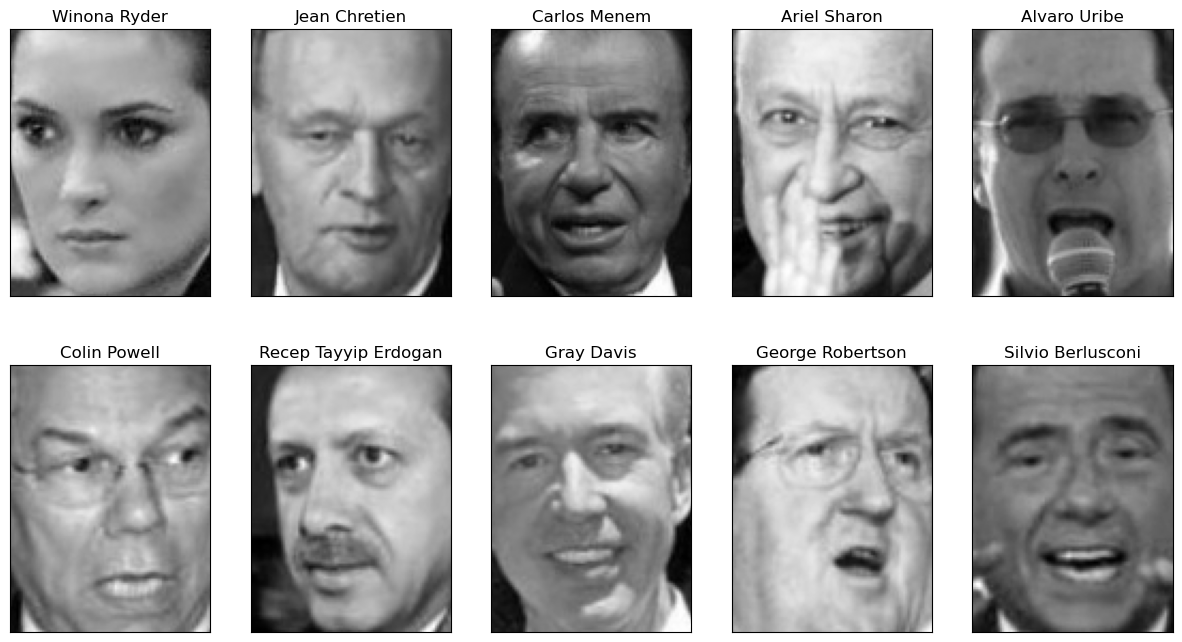

In [2]:
import matplotlib.pyplot as plt 

def plotimages(images, labels, rows=2, columns=5):
    fix, axes = plt.subplots(rows,columns,figsize=(15,rows*4),subplot_kw={'xticks': (), 'yticks':()})
    for image, label, ax in zip(images, labels, axes.ravel()):
        ax.imshow(image, cmap='gist_gray')
        #ax.imshow(image, cmap='viridis')
        ax.set_title(label)
    
plotimages(people.images, people.target_names[people.target])

**How similar are pictures of the same person?**

Compare multiple images of one person to see that lighting, pose, and expression still differ.

In [3]:
people.target_names[6]

np.str_('Arnold Schwarzenegger')

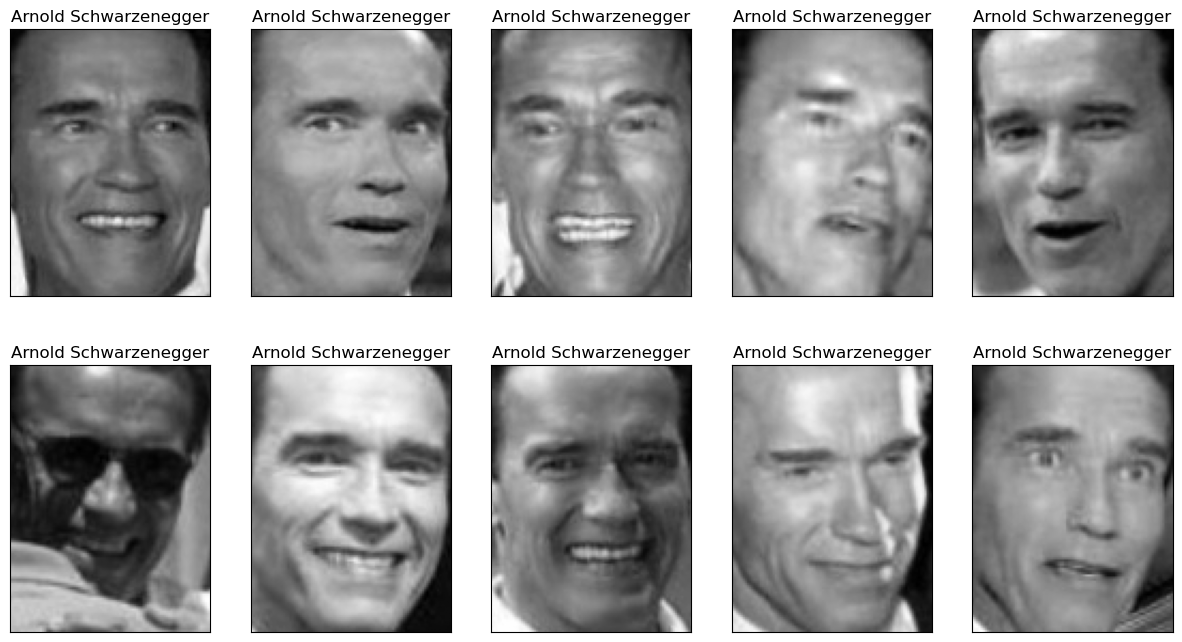

In [4]:
import matplotlib.pyplot as plt 
targetidx = 6;
cropped_images = people.images
arnieIdx = people.target==6
arnieimages = cropped_images[arnieIdx]
arnielabels = people.target[arnieIdx]

plotimages(arnieimages,people.target_names[arnielabels])

**Inspect data / number of samples per category**

Count the images per person before training so you can see how balanced the dataset is.

In [5]:
import numpy as np

def printtable(labels):
    counts = np.bincount(labels)
    for i, (count,name) in enumerate(zip(counts, people.target_names)):
        print("{0:25} {1:3}".format(name, count), end="    ")
        if (i+1)%2 == 0:
            print()
        
        
printtable(people.target)

Alejandro Toledo           39    Alvaro Uribe               35    
Amelie Mauresmo            21    Andre Agassi               36    
Angelina Jolie             20    Ariel Sharon               77    
Arnold Schwarzenegger      42    Atal Bihari Vajpayee       24    
Bill Clinton               29    Carlos Menem               21    
Colin Powell              236    David Beckham              31    
Donald Rumsfeld           121    George Robertson           22    
George W Bush             530    Gerhard Schroeder         109    
Gloria Macapagal Arroyo    44    Gray Davis                 26    
Guillermo Coria            30    Hamid Karzai               22    
Hans Blix                  39    Hugo Chavez                71    
Igor Ivanov                20    Jack Straw                 28    
Jacques Chirac             52    Jean Chretien              55    
Jennifer Aniston           21    Jennifer Capriati          42    
Jennifer Lopez             21    Jeremy Greenstock          24

**Take a maximum of 50 pictures per person**

Keep only a small fixed number of images per person to make the classes easier to compare.

In [6]:
mask = np.zeros(people.target.shape, dtype= bool)
for target in np.unique(people.target):
    mask[np.where(people.target==target)[0][:50]]=1
    

X_people = cropped_images[mask].reshape(-1,125*94)
y_people = people.target[mask]
X_people = X_people /255

#test
printtable(y_people)


Alejandro Toledo           39    Alvaro Uribe               35    
Amelie Mauresmo            21    Andre Agassi               36    
Angelina Jolie             20    Ariel Sharon               50    
Arnold Schwarzenegger      42    Atal Bihari Vajpayee       24    
Bill Clinton               29    Carlos Menem               21    
Colin Powell               50    David Beckham              31    
Donald Rumsfeld            50    George Robertson           22    
George W Bush              50    Gerhard Schroeder          50    
Gloria Macapagal Arroyo    44    Gray Davis                 26    
Guillermo Coria            30    Hamid Karzai               22    
Hans Blix                  39    Hugo Chavez                50    
Igor Ivanov                20    Jack Straw                 28    
Jacques Chirac             50    Jean Chretien              50    
Jennifer Aniston           21    Jennifer Capriati          42    
Jennifer Lopez             21    Jeremy Greenstock          24

**Classify with KNN**

Use a simple KNN baseline on the raw pixel vectors before reducing the dimensionality.

In [7]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#scaler = StandardScaler();
#scaler.fit(X_people)
#X_people = scaler.transform(X_people)

X_train, X_test, y_train, y_test = train_test_split(X_people, y_people, stratify=y_people, random_state=0)
print(X_train.shape)
print(y_train.shape)

knn= KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)

print("Score in Test", knn.score(X_test, y_test))

(1547, 11750)
(1547,)
Score in Test 0.2054263565891473


**Reduce dimensionality**

Compress the face images with PCA so the classifier works on a much smaller feature set.

In [8]:
from sklearn.decomposition import PCA 

pca = PCA(n_components=100, whiten=True, random_state=0)
pca.fit(X_train)

X_train_pca = pca.transform(X_train)  # 125*94 dim -> 100
X_test_pca = pca.transform(X_test)

print("Old Shape", X_train.shape)
print("New Shape", X_train_pca.shape)

Old Shape (1547, 11750)
New Shape (1547, 100)


**Is the new data a better representation for KNN?**

Check whether the PCA features improve KNN on unseen images.

In [9]:
knn= KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train_pca, y_train)

print("Score in Test", knn.score(X_test_pca, y_test)) # ~1 % better

Score in Test 0.29651162790697677


**Visualizing Principal Components**

Show the learned principal components as images to see what PCA thinks is important.

In [10]:
pca.components_.shape

(100, 11750)

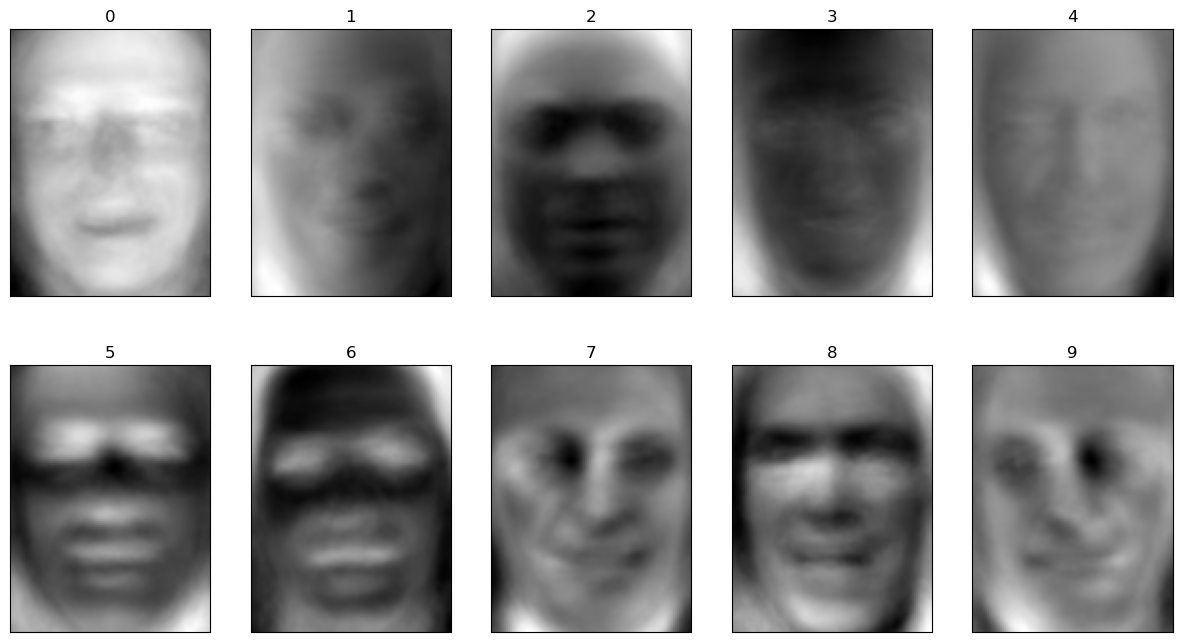

In [11]:
pc_images = pca.components_.reshape(-1, 125, 94) 
pc_labels = np.arange(100)
plotimages(pc_images, pc_labels,2,5)

**Reconstructing Arnie**

Take one example face and prepare it for reconstruction from PCA features.

Text(0.5, 1.0, 'Original Image')

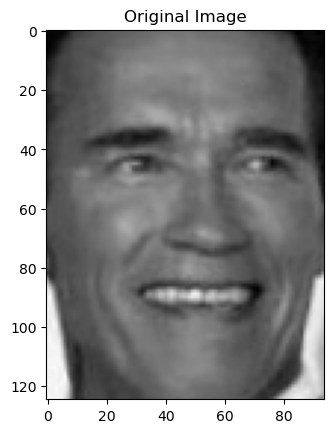

In [12]:
# getting an original arnie
arnieimage = arnieimages[0];  # this has dimension 125*94
plt.imshow(arnieimage, cmap='gist_gray')
plt.title("Original Image")

In [13]:
# Redo PCA training now with more components
pca = PCA(n_components=500, whiten=False, random_state=0)
pca.fit(X_train)

PCA(n_components=500, random_state=0)

In [14]:
arnieimage_stretched = arnieimage.reshape(1,125*94) # stretched out to 1x11750
transformed = pca.transform(arnieimage_stretched) # reducing dimensionality to 500
print("Input dimensions", arnieimage_stretched.shape)
print("Scaled down to dimensions", transformed.shape)

Input dimensions (1, 11750)
Scaled down to dimensions (1, 500)


**Reconstruct original image with inverse_transform**

Use the inverse transform to rebuild the image from its PCA representation.

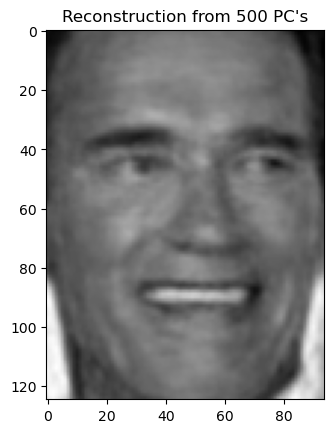

In [15]:
backtransformed = pca.inverse_transform(transformed)
plt.title("Reconstruction from {} PC's".format(len(pca.components_)))
plt.imshow(backtransformed.reshape(125,94), cmap='gist_gray')


**Reconstruct original image by hand** 

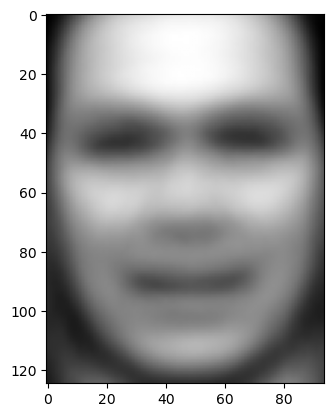

In [16]:
# we start with the mean image 
reconstruct = pca.mean_.reshape(125, 94)
plt.imshow(reconstruct, cmap='gist_gray')

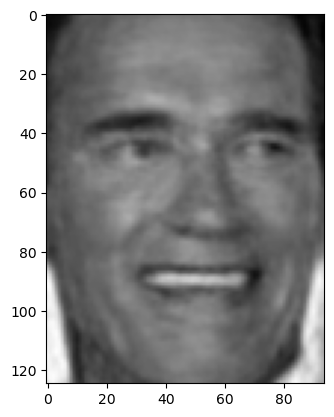

In [17]:
# we add the first principal components weighted by the transformed coefficients
for i in range(500):
    delta = pca.components_[i]*transformed[0][i]
    reconstruct = reconstruct + delta.reshape(125, 94)
    
plt.imshow(reconstruct, cmap='gist_gray')

# vectorized version of the for loop 
#r = pca.mean_ + transformed.dot(pca.components_) 
#r = r.reshape(125, 94)
#plt.imshow(r, cmap='gist_gray')


**Experiment: How many of the 11750 Dimensions are needed to recognize the person**

Try different numbers of components to see how much compression is still enough for recognition.

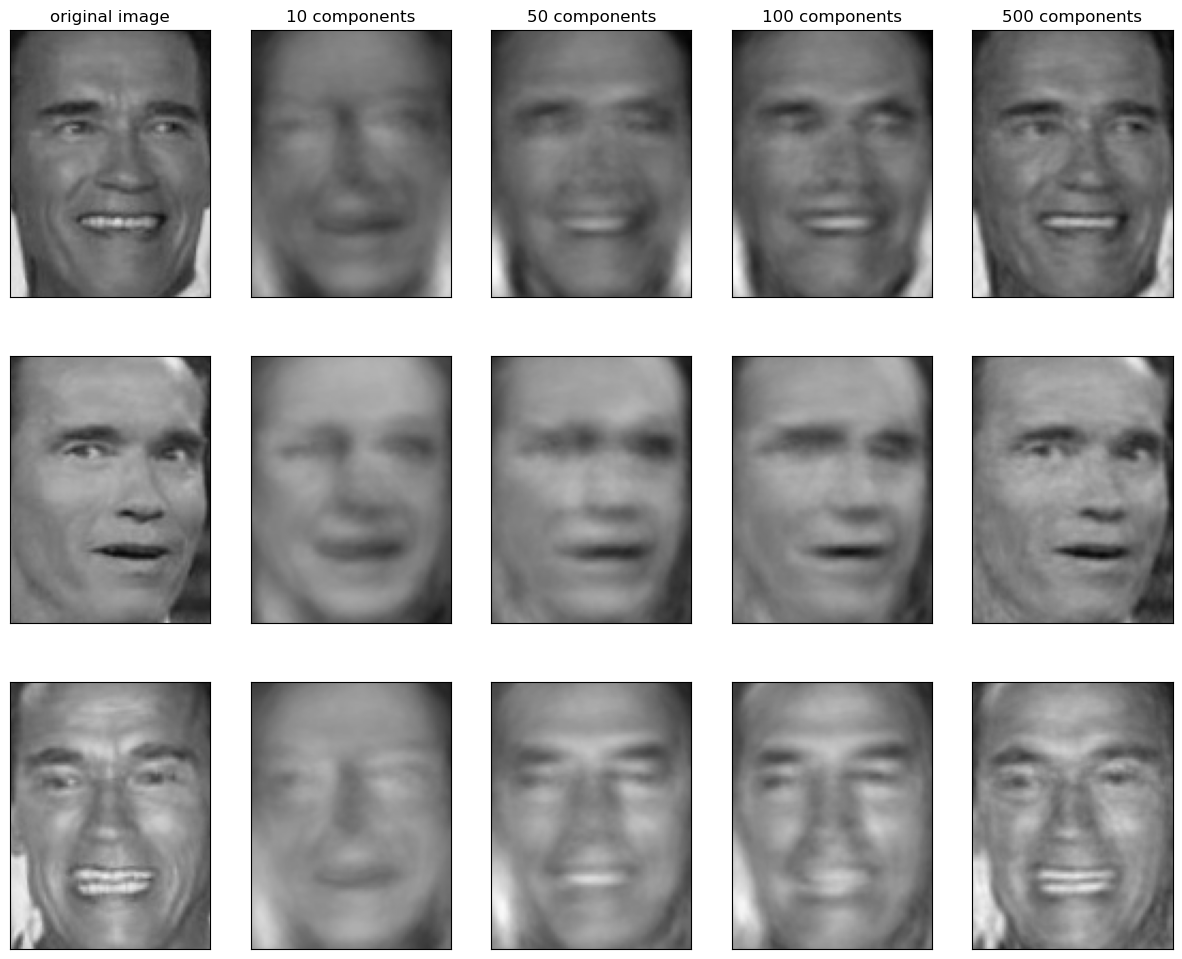

In [18]:
def pca_faces(X_train, X_test):
    reduced_images = []
    for n_components in [10, 50, 100, 500]:
        pca = PCA(n_components=n_components)
        pca.fit(X_train)
        # transform the test data (afterwards has n_components many dimensions)
        X_test_pca = pca.transform(X_test)
        # back-transform the transformed test-data
        # (afterwards it's in the original space again)
        X_test_back = pca.inverse_transform(X_test_pca)
        reduced_images.append(X_test_back)
    return reduced_images


def plot_pca_faces(X_train, X_test, image_shape):
    reduced_images = pca_faces(X_train, X_test)

    # plot the first three images in the test set:
    fix, axes = plt.subplots(3, 5, figsize=(15, 12),
                             subplot_kw={'xticks': (), 'yticks': ()})
    for i, ax in enumerate(axes):
        # plot original image
        ax[0].imshow(X_test[i].reshape(image_shape),
                     vmin=0, vmax=1, cmap='gist_gray')
        # plot the four back-transformed images
        for a, X_test_back in zip(ax[1:], reduced_images):
            a.imshow(X_test_back[i].reshape(image_shape), vmin=0, vmax=1, cmap='gist_gray')

    # label the top row
    axes[0, 0].set_title("original image")
    for ax, n_components in zip(axes[0, 1:], [10, 50, 100, 500]):
        ax.set_title("%d components" % n_components)
        
        
plot_pca_faces(X_train, (arnieimages).reshape(arnieimages.shape[0],125*94), (125, 94))

<BarContainer object of 100 artists>

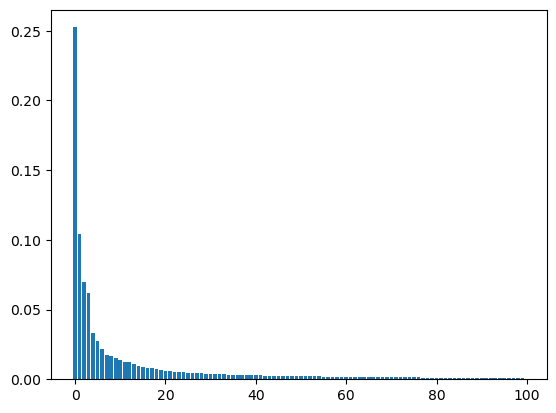

In [19]:
plt.bar(np.arange(100), pca.explained_variance_ratio_[0:100])

**Reconstruct some other promis**

Repeat the reconstruction idea on another face so you can compare the result on a different example.

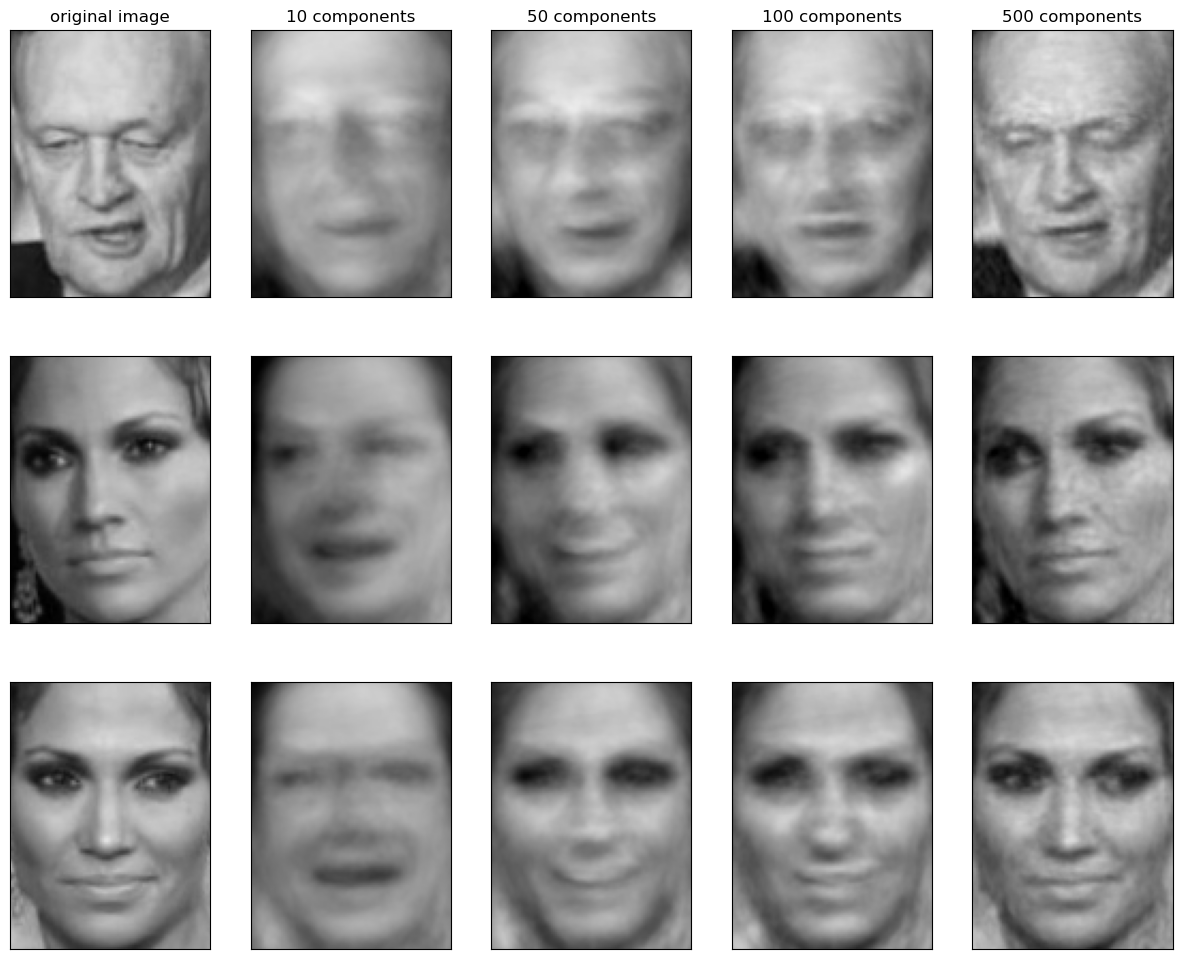

In [20]:
plot_pca_faces(X_train, X_test*255, (125, 94))